Variance of Laplacian: 245.7865188655536
(739, 400)


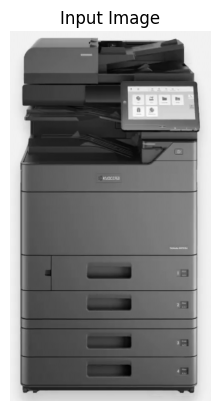

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/usr/src/app/data/output/crops/frame_00002_a_salient_object_00.png")  # Load the image
img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale

# Apply Laplacian filter
laplacian = cv2.Laplacian(img, cv2.CV_64F)

# Calculate variance of the Laplacian
# Higher variance indicates more edges/details, thus higher perceived sharpness
variance = np.var(laplacian)

print(f"Variance of Laplacian: {variance}")
print(img.shape)

#   Display the image (optional)
plt.imshow(img, cmap='gray')
plt.title('Input Image')
plt.axis('off')
plt.show()

In [19]:
import torch

def center_to_corners_format(boxes):
    """
    Args:
        boxes: (N, 4) テンソル。各行は [cx, cy, w, h] 形式
    Returns:
        (N, 4) テンソル。各行は [x1, y1, x2, y2] 形式
    """
    cx, cy, w, h = boxes.unbind(-1)
    x1 = cx - w / 2
    y1 = cy - h / 2
    x2 = cx + w / 2
    y2 = cy + h / 2
    return torch.stack([x1, y1, x2, y2], dim=-1)


batch_boxes = torch.tensor([[50, 60, 20, 40], [30, 40, 10, 10]], dtype=torch.float)
corners = center_to_corners_format(batch_boxes)
print(corners)

tensor([[40., 40., 60., 80.],
        [25., 35., 35., 45.]])


Video Intelligence

In [7]:
# !pip install google-cloud-videointelligence

In [1]:
from google.cloud import videointelligence

In [6]:
video_client = videointelligence.VideoIntelligenceServiceClient() # クライアントの初期化

In [7]:
# パス
import os
import io
from dotenv import load_dotenv

load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
video = "taskalfa.mp4"
video_path = os.path.join(DATA_DIR, video)

# 動画読み込み
with io.open(video_path, "rb") as movie:
    input_content = movie.read()

In [8]:
features = [videointelligence.Feature.LABEL_DETECTION] # 機能の指定（ここではラベル検出）

# リクエストの実行
operation = video_client.annotate_video(
    request={"features": features, "input_content": input_content}
)

operation

In [9]:
result = operation.result()

In [11]:
result

annotation_results {
  segment_label_annotations {
    entity {
      entity_id: "/m/0dwx7"
      description: "logo"
      language_code: "en-US"
    }
    category_entities {
      entity_id: "/m/021sdg"
      description: "graphics"
      language_code: "en-US"
    }
    segments {
      segment {
        start_time_offset {
        }
        end_time_offset {
          seconds: 74
          nanos: 941533000
        }
      }
      confidence: 0.487938404
    }
  }
  segment_label_annotations {
    entity {
      entity_id: "/m/0c5mq"
      description: "printing"
      language_code: "en-US"
    }
    category_entities {
      entity_id: "/m/0jjw"
      description: "art"
      language_code: "en-US"
    }
    segments {
      segment {
        start_time_offset {
        }
        end_time_offset {
          seconds: 74
          nanos: 941533000
        }
      }
      confidence: 0.713107407
    }
  }
  segment_label_annotations {
    entity {
      entity_id: "/m/01cd9"
      d

In [14]:
# バッチ処理の数だけレスポンスがある
result.annotation_results[0]

segment_label_annotations {
  entity {
    entity_id: "/m/0dwx7"
    description: "logo"
    language_code: "en-US"
  }
  category_entities {
    entity_id: "/m/021sdg"
    description: "graphics"
    language_code: "en-US"
  }
  segments {
    segment {
      start_time_offset {
      }
      end_time_offset {
        seconds: 74
        nanos: 941533000
      }
    }
    confidence: 0.487938404
  }
}
segment_label_annotations {
  entity {
    entity_id: "/m/0c5mq"
    description: "printing"
    language_code: "en-US"
  }
  category_entities {
    entity_id: "/m/0jjw"
    description: "art"
    language_code: "en-US"
  }
  segments {
    segment {
      start_time_offset {
      }
      end_time_offset {
        seconds: 74
        nanos: 941533000
      }
    }
    confidence: 0.713107407
  }
}
segment_label_annotations {
  entity {
    entity_id: "/m/01cd9"
    description: "brand"
    language_code: "en-US"
  }
  segments {
    segment {
      start_time_offset {
      }
      end

In [15]:
segment_labels = result.annotation_results[0].segment_label_annotations

In [16]:
len(segment_labels)

4

In [22]:
segment_labels[1]

entity {
  entity_id: "/m/0c5mq"
  description: "printing"
  language_code: "en-US"
}
category_entities {
  entity_id: "/m/0jjw"
  description: "art"
  language_code: "en-US"
}
segments {
  segment {
    start_time_offset {
    }
    end_time_offset {
      seconds: 74
      nanos: 941533000
    }
  }
  confidence: 0.713107407
}

In [20]:
for sl in segment_labels:
    print(sl.entity.description)

logo
printing
brand
printer


In [24]:
shot_labels = result.annotation_results[0].shot_label_annotations

In [ ]:
shot_labels[4]

In [27]:
len(shot_labels)

19

In [32]:
features = [videointelligence.Feature.OBJECT_TRACKING] # 機能の指定

# リクエストの実行
operation = video_client.annotate_video(
    request={"features": features, "input_content": input_content}
)

operation

In [33]:
result = operation.result()

In [ ]:
result

In [11]:
"""All Video Intelligence API features run on a video stored on GCS."""
from google.cloud import videointelligence

import time

gcs_uri = "gs://dev-moton-app/video/side_mirror.mp4"
output_uri = "gs://dev-moton-app/logs/mirror_output-{}.json".format(time.time())
output_uri

'gs://dev-moton-app/logs/mirror_output-1753362196.378774.json'

In [12]:
import os
from dotenv import load_dotenv
load_dotenv()

GOOGLE_APPLICATION_CREDENTIALS = os.environ["GOOGLE_APPLICATION_CREDENTIALS"]

In [13]:
video_client = videointelligence.VideoIntelligenceServiceClient()
video_client

In [14]:
features = [
    videointelligence.Feature.OBJECT_TRACKING,
    videointelligence.Feature.LABEL_DETECTION,
    videointelligence.Feature.SHOT_CHANGE_DETECTION,
    videointelligence.Feature.SPEECH_TRANSCRIPTION,
    videointelligence.Feature.LOGO_RECOGNITION,
    videointelligence.Feature.EXPLICIT_CONTENT_DETECTION,
    videointelligence.Feature.TEXT_DETECTION,
    videointelligence.Feature.FACE_DETECTION,
    videointelligence.Feature.PERSON_DETECTION
]

transcript_config = videointelligence.SpeechTranscriptionConfig(
    language_code="en-US", enable_automatic_punctuation=True
)

person_config = videointelligence.PersonDetectionConfig(
    include_bounding_boxes=True,
    include_attributes=False,
    include_pose_landmarks=True,
)

face_config = videointelligence.FaceDetectionConfig(
    include_bounding_boxes=True, include_attributes=True
)


video_context = videointelligence.VideoContext(
    speech_transcription_config=transcript_config,
    person_detection_config=person_config,
    face_detection_config=face_config)

operation = video_client.annotate_video(
    request={"features": features,
             "input_uri": gcs_uri,
             "output_uri": output_uri,
             "video_context": video_context}
)

print("\nProcessing video.", operation)

result = operation.result(timeout=300)

print("\n finnished processing.")

# print(result)


Processing video. <google.api_core.operation.Operation object at 0x7f8d929cf820>

 finnished processing.


In [10]:
result

annotation_results {
  input_uri: "/dev-moton-app/video/taskalfa.mp4"
  segment_label_annotations {
    entity {
      entity_id: "/m/0dwx7"
      description: "logo"
      language_code: "en-US"
    }
    category_entities {
      entity_id: "/m/021sdg"
      description: "graphics"
      language_code: "en-US"
    }
    segments {
      segment {
        start_time_offset {
        }
        end_time_offset {
          seconds: 74
          nanos: 941533000
        }
      }
      confidence: 0.487938404
    }
  }
  segment_label_annotations {
    entity {
      entity_id: "/m/01m4t"
      description: "printer"
      language_code: "en-US"
    }
    category_entities {
      entity_id: "/m/07c1v"
      description: "technology"
      language_code: "en-US"
    }
    segments {
      segment {
        start_time_offset {
        }
        end_time_offset {
          seconds: 74
          nanos: 941533000
        }
      }
      confidence: 0.919685483
    }
  }
  segment_label_annota